In [1]:
import numpy as np
from scipy.spatial import distance_matrix
import networkx as nx
from sage.groups import *
from sage.graphs import *
from sage.graphs.generators.random import RandomGNP
from sage.graphs.spanning_tree import *
from sage.graphs.distances_all_pairs import *
import random
from itertools import chain, combinations
import math
from scipy.optimize import linprog
import time
# import minihit # Solver for minimal hitting set problems, from https://github.com/TheMatjaz/minihit/tree/master
#Plotting
from matplotlib import pyplot as plt
# from concurrent.futures import ProcessPoolExecutor
from sage.graphs.connectivity import connected_components_subgraphs
import pandas as pd 
from scipy import sparse

from sage.graphs.distances_all_pairs import floyd_warshall
from sage.graphs.base.boost_graph import floyd_warshall_shortest_paths


In [2]:
def check_symmetric(a, tol=1e-8):
    return np.all(np.abs(a-a.T) < tol)

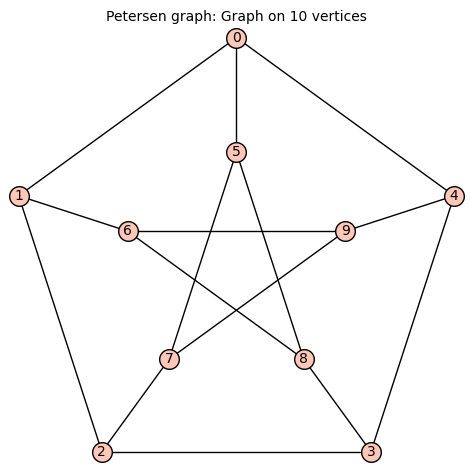

# Coherence

In [ ]:
def com_coh(D,p):
    N = D.shape[0]
    """Calculate the comulative coherence (babel function) of the redundant dictionary D. We do not assume that
    the atoms of D are normalized, but we do assume that they have norm >=1""" 
    # This is reasonable for our useage - the norms of our "atoms" are at least 3
    S = D @ np.transpose(D) 
    S = abs(S)
    S = np.sort(-S,axis=1)*-1 # sort rows in descending order
    # By Cauchy Schwartz and our assumption on the norms S_{i,1}  = \norm(D_i), so we can ignore it
#     S = np.transpose(S) # for runtime purposes - now columns are ordered
    rowSum = np.cumsum(S[:,1:],1) #Calculate partial sums of rows, ignoring the first one
    # the j'th column of rowSum now holds the partial sums of $j$ atoms with $i$ (no two are the same).
    # So mu_1(p) is the maximum value of the j'th column. The p-1 here is because indices are a bitch
    return max(rowSum[:,p-1]) 
        

    

# Cycle Fucntions

In [2]:
### Check broken triangles

def is_triangle(E,i,j,k):
    """ Check if a given 3 indecies make a triangle in E(G)"""
    return tuple(sorted([i,j])) in E and tuple(sorted([i,k])) in E and tuple(sorted([j,k])) in E


def metric_triangles_mtx(G):
    """Returns the metric testing matrix for broken triangles"""
    D = make_index_encoding(G)
    I = get_edge_inedcies(G,D)
    n = G.order()
    E = G.edges(sort=True,labels=False)
    e = G.size()
    M = np.zeros(e)
    changed = 0
    for T in combinations(range(e),3):
        if is_triangle(E,T[0],T[1],T[2]):
            changed = 1
            T_edges = list(combinations(T,2))
            for i in range(3):
                z = np.zeros(e)
                z[D[T_edges[(0+i)%3]]] = 1
                z[D[T_edges[(1+i)%3]]] = 1
                z[D[T_edges[(2+i)%3]]] = -1
                M = np.vstack((M,z))
    if not changed:
        return M
    M = np.delete(M,0,0)
    return M

### Generate the metric testing matrix for a graph G
def induced_cycle_matrix(G):
    m = G.num_edges()
    ind_enc = make_index_encoding(G)
    mtxs = list()
    count = 0
    for C in get_chordless_cycles(G):
        count +=1
        M = np.zeros(m)
        C_ind = [*map(ind_enc.get, C)] # All indiced of the relevant edges
        for ind in C_ind:
            newrow = np.zeros(m)
            newrow[C_ind] = 1
            newrow[ind] = -1
            M = np.vstack((M, newrow))
        mtxs.append(sparse.csc_matrix(M))
    if count == 0:
        return np.zeros(m),count
    Phi = mtxs[0]
    for i in range(1,len(mtxs)):
        Phi = sparse.vstack((Phi,mtxs[i]))
    return Phi, count
        
def get_list_of_edges(cyc_vtx):
    """ Given a list of vertices of a cycle in the graph, return all its edges"""
    k = len(cyc_vtx)
    return [tuple(sorted((cyc_vtx[i],cyc_vtx[(i+1) % k]))) for i in range(k)]

def get_chordless_cycles(G):
    """Generator of all chordless cycles of a graph G. Just needs to transform it to networkx object and 
    call that function"""
    g = G.copy()
    for C in nx.chordless_cycles(g.networkx_graph()):
        yield get_list_of_edges(C)

# fuctions for weights and indices
def set_weights(G,W):
    """expects W to be a list of values, ordered to fit the order of edges in G"""
    assert G.size() == len(w)
    i = 0
    for e in G.edges(sort = True):
        G.set_edge_label(e[0],e[1],W[i])
        i+=1
def get_weights(G):
    """Gets a dictionary of the function w:E -> weights"""
    assert G.weighted()
    D = dict()
    for e in G.edges(sort=True):
        D[(e[0],e[1])] = e[2]
    return D
def get_weights_vector(G,D):
    """expects D an encoding of E->[n], and returns a vector where the indices """
    w_dict = get_weights(G)
    w = np.zeros(G.size())
    for edge,weight in w_dict.items():
        w[D[edge]] = w_dict[edge]
    return w
    
def update_weights(G,Wp, ind_enc):
    """Given a weighted graph G, additional weights Wp and an index encoding ind_enc - sets new weights w+Wp """
    Dw = get_weights(G)
    for i in np.nonzero(Wp)[0]:
        e = ind_enc[i]
        G.set_edge_label(e[0],e[1], Dw[e] + Wp[i])

        
def get_edge_inedcies(G,D):
    """ Given a graph G and indices encoding of its edges D:[n] -> E, returns the inverse dictionary"""
    return {index : edge for edge,index in D.items()}


def make_index_encoding(G):
    """ Encode the edges of $G$ to indices, ignores labels and sorts edges (small,large)
    D: E -> [n]"""
    return dict(tuple(zip(G.edges(sort=True,labels=False),range(G.num_edges()))))

### Auxiliary stuff
def count_simple_cycles(G,kmin = 3, kmax = 0):
    if kmin < 3:
        kmin = 3
    
    if kmax > G.order() or kmax == 0:
        kmax = G.order()
    S = 0
    for k in range(kmin,kmax+1):
        H = graphs.CycleGraph(k)
        S += G.subgraph_search_count(H,induced = True)/H.automorphism_group(return_group=False,order=True)
    return S

# Metric Repair Functions


In [ ]:
def is_metric(G):
    """ Assumes G is a weighted Graph"""
    apsp = G.distance_all_pairs(by_weight=True)
    for e in G.edges(sort=True):
        if e[2] != apsp[e[0]][e[1]]:
            return False
    return True
        

def verifier(G,S):
    """Verify if S is a cover of G. If so, return a valid solution."""
    H = G.copy()
    M = max(G.edge_labels())
    for e in S:
        H.set_edge_label(e[0],e[1],M)
    D = H.distance_all_pairs(by_weight=True)
    for u,v,w in H.edges(sort=True):
        if D[u][v] != w:
            H.set_edge_label(u,v,D[u][v])
            if (u,v) not in S and (v,u) not in S:
                return 0
    return 1

### Heuristics ###

def Gilbert_Jain_IOMR(Kn):
    """The Gilbert & Lalit heuristic - just arbitrarily pick and edge to fix in a broken triangle.
    Assumes input is Complete."""
    H = Kn.copy()
    M = H.weighted_adjacency_matrix()
    n = M.nrows()
    S = set()
    for k in range(n):
        for i in range(n):
            for j in range(i):
                if M[i,j] > M[i,k] + M[k,j]:
                    M[i,k] = M[i,j] - M[k,j]
                    S.add(tuple(sorted((i,k))))

    return S


def MVD_Pivot_Rec(ind,x,S,Kn):
    """I will think of x as the symmetric adjacency matrix and M as the fixed copy of the 
     adjacency matrix which we augment along the way"""
    if len(ind) <=2:
        return
    i = np.random.choice(ind)
    
    ind_i = ind.copy() #make sure we don't change the input
    ind_i.remove(i) # Remove the current pivot
    
    for j,k in list(combinations(ind_i,2)): #iterate over all triangles i,j,k
        ADD = False #flag - do we change the edge?
        if x[j,k] > x[i,j] + x[i,k]:
            x[j,k] = x[i,j] + x[i,k]
            ADD=True
        if x[j,k] < np.abs(x[i,j] - x[i,k]):
            x[j,k] = np.abs(x[i,j] - x[i,k])
            ADD=True
        if ADD:
            S.add(tuple(sorted((j,k))))
            
    MVD_Pivot_Rec(ind_i,x,S,Kn)
    return
        
def MVD_Pivot(Kn):
    """The algorithm from Fitting Metrics with Minimum Disagreement. This one solves a general MR, not IOMR"""
    A = Kn.weighted_adjacency_matrix()
    S = set()
    MVD_Pivot_Rec(list(range(Kn.num_verts())),A,S,Kn)
    T = np.triu(A)
    return S


def reduce_solution(S,G,Diff = []):
    """Takes a graph G and an extended HS S and reduces it to a HS for G (discards edges that are not in G).
    Diff is a matrix that allows to check if an edge was actually changed if needed"""
#     print(len(S))
    reduced_S = set()
    for e in G.edges(labels=False, sort=True): #check all edges
        if e in S:
            reduced_S.add(e) #if it hits a broken cycle, add it
    return reduced_S
    


#### This is basically done now, just need to run some tests and then actually run it.
def l1_min_heuristic(G):
    """Solves metric repair by creating an l1 minimization problem. That is:
    1. Complete the graph G, obtain Gc
    2. Create the metric constraint matrix Phi, which checks all triangle inequalities in Gc
    3. Solve L1 minimization, guaranteed to satisfy all triangle inequalities
    4. Take the intersection of E(G) with the support of the solution. Since no broken triangles remain, that means
    no broken cycles in general remain, so the intersection must be a light cover of G"""
    
    ## Preprocess - comlplete the graph and get index dictionaries
    Gc = complete(G)
    D = make_index_encoding(Gc)
    w = get_weights_vector(Gc,D)
    
    ## Set up the minimization problem
    phi = induc(Gc)
    Phi = np.transpose(phi)
    m,n = Phi.shape
    b = np.transpose(Phi) @ w
    c = np.ones(m)
    con = -np.transpose(Phi)
    
    ## Solve minimization problem
    soln = linprog(c,A_ub = con, b_ub = b, method = 'simplex') 
    
    ## Retrieve the support of solution
    S = set()
    for e in G.edges(sort=True):
        if soln.x[D[(e[0],e[1])]] > 0:
            S.add((e[0],e[1]))
    return S

def l1_minimization(Gc):
    """ The same as l1 min but without completion """
    phi = induced_cycle_matrix(Gc)
    if phi[1] == 0:
        return set()
    else:
        phi = phi[0]
    Phi = np.transpose(phi)
    D = make_index_encoding(Gc)
    w = get_weights_vector(Gc,D)
    # print(Gc.edges(sort=True))
    m,n = Phi.shape
    b = np.transpose(Phi) @ w
    c = np.ones(m)
    con = -np.transpose(Phi)
    soln = linprog(c,A_ub = con, b_ub = b, method = 'highs') 
    x = soln.x
    S = set()
    for e in Gc.edges(sort=True):
        if x[D[(e[0],e[1])]] > 0:
            S.add((e[0],e[1]))
    return S

def domr_alg(G,with_weights=0):
    S = set()
    apsp = G.distance_all_pairs(by_weight=True)
    for e in G.edges(sort=True):
        if e[2] != apsp[e[0]][e[1]]:
            if with_weights:
                S.add(e)
            else:
                S.add((e[0],e[1]))
    return(S)


def left_edge_heuristic(G):
    Kn = complete(G)
    S = Gilbert_Jain_IOMR(Kn)
    return reduce_solution(S,G)
    

def pivot_heuristic(G):
    Kn = complete(G)
    S = MVD_Pivot(Kn)
    return reduce_solution(S,G)

def find_shortest_path(u,v,Dict):
    """
    Given a dictionary of predecessors, find a shortest path between u,v
    """
    start = u
    end = v
    P = list()
    while end != u:
        w = Dict[u][end] ## find a predecessor of end
        P.append(tuple(sorted((end,w)))) #add that edge to the list
        end = w #w is new endpoint
    return P


### Gives an L+1 (or L) approximation for Graph Metric Repair
def shortest_path_cover(G,general = True):
    H = G.copy()
    D = get_weights(G)
#     A = H.weighted_adjacency_matrix()
    S = set()
    while True:
        dist, Dict = floyd_warshall_shortest_paths(H,predecessors=1,distances=1)
        found_broken = 0
        for u,v,w in H.edges(sort=True):
            if D[(u,v)] > dist[u][v]:
                found_broken = 1
                P = find_shortest_path(u,v,Dict)
                if general:
                    S.add((tuple(sorted((u,v)))))
                    H.delete_edge((u,v))
                S.update(P)
                H.delete_edges(P)
        if not found_broken:
            return S

        
### Heuristic: Remove edges that necessarily don't participate in broken cycles, and then find DOMR solution

def on_broken_cycle(e,e_heavy,APSP_D,w_heavy,w_light):
    i,j =e
    x,y = e_heavy
#     print(w_light + APSP_D[i][x] + APSP_D[j][y])
#     print(w_light+ APSP_D[i][y] + APSP_D[j][x])
    return not ((w_light + APSP_D[i][x] + APSP_D[j][y] >= w_heavy) and (w_light+ APSP_D[i][y] + APSP_D[j][x] >= w_heavy))

def get_truly_light_edges(G,Heavy_Edges,APSP_D):
    """ Returns a collection of edges that definitely don't participate in any broken cycle, by checking a
    'four point condition', that shortest paths distances make sense"""
    Light_Edges = set(G.edges()) - Heavy_Edges
    Remove = set()
    for e in Light_Edges:
        remove = True
        for e_heavy in Heavy_Edges:
            if on_broken_cycle(e[:-1],e_heavy[:-1],APSP_D,e_heavy[-1],e[-1]):
                remove = False
                break
        if remove:
            Remove.add(e)
    return Light_Edges - Remove

def truly_light_heuristic(G):
    """This is an algorithm that has no reason to work well. Discard truly light edges, 
    and then return the cycle dimension. thing is, OPT is always smaller than DOMR smaller than cycle dimension..."""
    APSP_D = G.shortest_path_all_pairs(by_weight=1)[0]
    Heavy_Edges = domr_alg(G,with_weights=1)
    
    Truly_Light = get_truly_light_edges(G,Heavy_Edges,APSP_D)
    print(Heavy_Edges | Truly_Light)
    H = Graph(weighted=1)
    H.add_edges(Heavy_Edges | Truly_Light)
    return H.size() - H.order() + 1,H
    
    

In [ ]:
## Networkx Implementations
def shortest_path_cover(G):
    """ Given a graph G, finds a shortest path cover"""
    H = G.copy()
    

# Graph Generators


In [34]:
def random_weighted_graph(n, p, lower_weight = 1, upper_weight = 100): 
    # Does not take metrics into account, just a regular random graph
    g = graphs.RandomGNP(n,p)
    m = g.num_edges()
    weights = [random.randint(lower_weight, upper_weight) for r in range(m)]
    uw_edges = g.edges(sort = True)
    
    # Create weighted graph edge list 
    w_edges = [(uw_edges[i][0], uw_edges[i][1], weights[i]) for i in range(m)]
    
    return Graph(w_edges, weighted = True)


def random_geometric_weighted_graph(n,p): ### Not a good name!
    """Returns a random graph where the edges' weight distribution is Geo(1-p)"""
    g = graphs.RandomGNP(n,p)
    m = g.num_edges()
    weights = np.random.geometric(1-p,m)
    uw_edges = g.edges(sort = True)
    
    # Create weighted graph edge list 
    w_edges = [(uw_edges[i][0], uw_edges[i][1], weights[i]) for i in range(m)]
    
    return Graph(w_edges, weighted = True)    
    
def get_mst(G):
    # Using Kruskal, don't know if that changes anything
    return G.subgraph(G.vertices(sort = False),filter_kruskal(G))

def random_metric_graph(n,p):
    #get a random graph with distances that adhere to a metric (Euclidean!)
    g = graphs.RandomGNP(n,p)
    while not g.is_connected(): # Can change to biconnected if feels like it
        g = graphs.RandomGNP(n,p)
    vects = [np.random.randint(0,high=15,size=5) for i in range(n)]
    D = distance_matrix(vects,vects)
    m = g.num_edges()
    uw_edges = g.edges(sort = False)
    w_edges = [(e[0],e[1],D[e[0],e[1]]) for e in uw_edges]
    
    return Graph(w_edges, weighted = True)

def random_uniform_weighted_graph(n,p):
    """Not clear if this is OK. Generates G(n,p) with weights that are distributed uniformly and then thresholded"""
    g = graphs.CompleteGraph(n)
    m=g.num_edges()
    weights = np.random.uniform(size=m)
    uw_edges = g.edges(sort = True)

#     for e,i in enumerate(g.edges(sort=True)):
#         if weights[i] > p:
    w_edges = [(uw_edges[i][0], uw_edges[i][1], weights[i]) for i in range(m) if weights[i] > 1-p ]   
    return Graph(w_edges, weighted = True)    
            
def uniform_complete_graph(n,L=0,U=1):
    """generates a complete graph with edges distributed uniformly [L,U]"""
    g = graphs.CompleteGraph(n)
    m=g.num_edges()
    weights = np.random.uniform(low = L, high = U,size=m)
    uw_edges = g.edges(sort = True)
    w_edges = [(uw_edges[i][0], uw_edges[i][1], weights[i]) for i in range(m)]   
    return Graph(w_edges, weighted = True)    
def complete(G):
    # Todo: When G is disconnected we need to take care of this somehow.
    """Given a weighted graph G, adds the missing edges to G with w(xy) := dist(xy)"""
    H = G.copy()
    Gc = G.complement()
    D = G.distance_all_pairs(by_weight=True)
    H.add_edges([(e[0],e[1],D[e[0]][e[1]]) for e in Gc.edges(sort=True)])
    return H


def geometric_complete_graph(n,p):
    K = graphs.CompleteGraph(n)
    for u,v in K.edges(labels=0, sort=1):
        K.set_edge_label(u,v, np.random.geometric(1-p) - 1)
    return K


def random_exponential_weighted_graph(n,p): ### Not a good name!
    """Returns a random graph where the edges' weight distribution is Geo(1-p)"""
    g = graphs.RandomGNP(n,p)
    m = g.num_edges()
#     weights = np.random.geometric(1-p,m)
    uw_edges = g.edges(sort = True)
    w_edges = [0 for i in range(m)]
    for i,e in enumerate(uw_edges):
        w = 0
        while w<1:
            w = np.random.exponential(np.log(1/p))
        
        w_edges[i] = (e[0],e[1],w)
    # Create weighted graph edge list 
#     w_edges = [(uw_edges[i][0], uw_edges[i][1], weights[i]) for i in range(m)]
#     print()
    return Graph(w_edges, weighted = True)

def get_subdivided_graph(G):
    """ Given a weighted graph G, returns an unweighted graph H obtained by subdividing each edge e into w(e) edges"""
    H = G.copy()
    for e in G.edges(labels=False,sort=True):
        k = G.edge_label(e[0],e[1])-1
        H.set_edge_label(e[0],e[1],1)
        H.subdivide_edge(e,k)
    return H

## Interesting Examples Generators?

In [ ]:
### Interesting Example ###

# V = list(range(6))
# E = [(1,2,1),(2,3,1),(1,4,1),(2,4,1),(2,5,5),(4,5,1),(4,6,1),(5,6,1),(3,5,1)]
# R = Graph(weighted=True)
# R.add_edges(E)
# R.show(edge_labels=1)

In [8]:
# N=100
# AVG_diam = 0
# for i in range(N):
#     G = random_geometric_weighted_graph(50,.5)
#     D = G.distance_all_pairs(by_weight=True)
#     d_max = 0
#     for e in G.edges(sort=True):
#         curr = D[e[0]][e[1]]
#         if curr > d_max:
#             d_max = curr
#     AVG_diam+=d_max/N
# print(AVG_diam)

# AVG_diam = 0
# for i in range(N):
#     G = random_geometric_weighted_graph(50,.9)
#     D = G.distance_all_pairs(by_weight=True)
#     d_max = 0
#     for e in G.edges(sort=True):
#         curr = D[e[0]][e[1]]
#         if curr > d_max:
#             d_max = curr
#     AVG_diam+=d_max/N
# print(AVG_diam)

# AVG_diam = 0
# for i in range(N):
#     G = random_geometric_weighted_graph(50,.2)
#     D = G.distance_all_pairs(by_weight=True)
#     d_max = 0
#     for e in G.edges(sort=True):
#         curr = D[e[0]][e[1]]
#         if curr > d_max:
#             d_max = curr
#     AVG_diam+=d_max/N
# print(AVG_diam)